In [1]:
import os
import sys
import datetime as dt
import cmocean as cmo

import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import haversine, hp_mods, get_nn_lon_lat_index

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/franmorr/.conda/envs/hk26_env/share/proj failed


In [2]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
# sim = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
pr = ds.pr*3600*24
pr["units"]="mm day-1"

Text(0.5, 1.0, 'Local summer - local winter\ndaily mean rainfall difference\nis greater than 2mm/day')

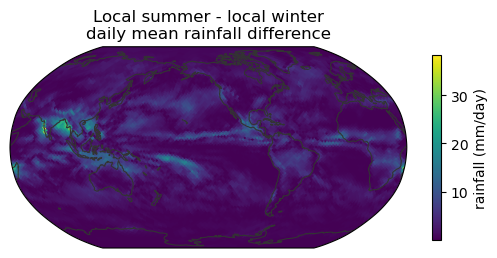

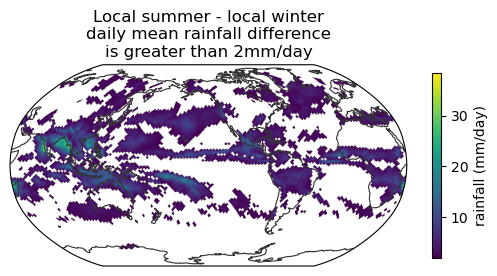

In [3]:
DJFM = pr.sel(time=slice("2020-12-01", "2021-03-31")).mean(dim="time")
JJAS = pr.sel(time=slice("2020-06-01", "2020-09-30")).mean(dim="time")
diff = abs(DJFM - JJAS)
im = egh.healpix_show(diff)
plt.colorbar(im, label="rainfall (mm/day)", shrink=0.5)
plt.title("Local summer - local winter\ndaily mean rainfall difference")
plt.figure()
im = egh.healpix_show(diff.where(diff > 2))
plt.colorbar(im, label="rainfall (mm/day)", shrink=0.5)
plt.title(
    "Local summer - local winter\ndaily mean rainfall difference\nis greater than 2mm/day"
)

Text(0.5, 1.0, 'Local summer mean rainfall')

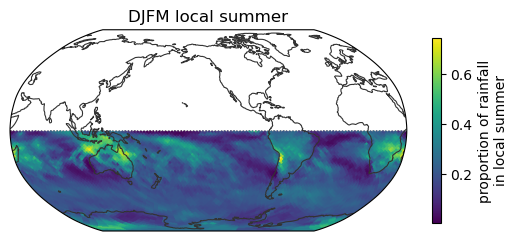

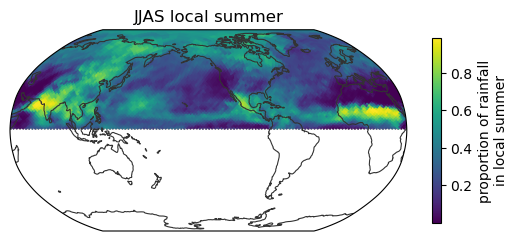

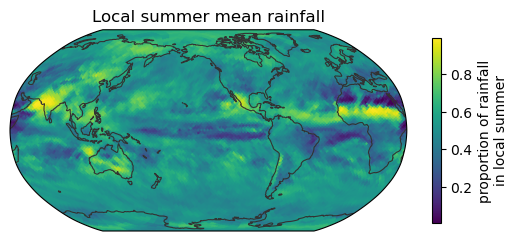

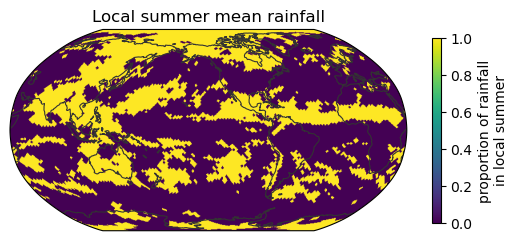

In [11]:
djfm_summer = (DJFM - JJAS) > 0
djfm_summer = (DJFM.lat) < 0
annual_sum_djfm_summer = pr[:, djfm_summer.values].sum(dim="time")
djfm_sum_djfm_summer = pr.sel(time=slice("2020-12-01", "2021-03-31")).sum(dim="time")
plt.figure()
im = egh.healpix_show(djfm_sum_djfm_summer / annual_sum_djfm_summer)
plt.colorbar(im, label="proportion of rainfall\nin local summer", shrink=0.5)
plt.title("DJFM local summer")

jjas_summer = (JJAS - DJFM) > 0
jjas_summer = (JJAS.lat) > 0

annual_sum_jjas_summer = pr[:, jjas_summer.values].sum(dim="time")
jjas_sum_jjas_summer = pr.sel(time=slice("2020-06-01", "2020-09-30")).sum(dim="time")
plt.figure()
im = egh.healpix_show(jjas_sum_jjas_summer / annual_sum_jjas_summer)
plt.colorbar(im, label="proportion of rainfall\nin local summer", shrink=0.5)
plt.title("JJAS local summer")

annual_sum=pr.sum(dim="time")
all_sum_local_summer = djfm_sum_djfm_summer+jjas_sum_jjas_summer
plt.figure()
im = egh.healpix_show(all_sum_local_summer / annual_sum)
plt.colorbar(im, label="proportion of rainfall\nin local summer", shrink=0.5)
plt.title("Local summer mean rainfall")

plt.figure()
im = egh.healpix_show(all_sum_local_summer / annual_sum > 0.55)
plt.colorbar(im, label="proportion of rainfall\nin local summer", shrink=0.5)
plt.title("Local summer mean rainfall")

In [14]:
def get_proportion(pr, DJFM=None, JJAS=None, proportion=0.55, localsummer="lat"):
    if DJFM == None:
        DJFM = pr.sel(time=slice("2020-12-01", "2021-03-31")).mean(dim="time")
    if JJAS == None:
        JJAS = pr.sel(time=slice("2020-06-01", "2020-09-30")).mean(dim="time")
    
    if localsummer == "lat":
        jjas_summer = JJAS.lat > 0
        djfm_summer = DJFM.lat < 0
    elif localsummer=="rain":
        jjas_summer = (JJAS - DJFM) > 0
        djfm_summer = (DJFM - JJAS) > 0
    annual_sum_djfm_summer = pr[:, djfm_summer.values].sum(dim="time")
    djfm_sum_djfm_summer = pr.sel(time=slice("2020-12-01", "2021-03-31")).sum(
        dim="time"
    )
    annual_sum_jjas_summer = pr[:, jjas_summer.values].sum(dim="time")
    jjas_sum_jjas_summer = pr.sel(time=slice("2020-06-01", "2020-09-30")).sum(
        dim="time"
    )
    annual_sum = pr.sum(dim="time")
    all_sum_local_summer = djfm_sum_djfm_summer + jjas_sum_jjas_summer
    proportion_local_summer = all_sum_local_summer / annual_sum
    return proportion_local_summer

def restrict_proportion(pr, DJFM=None, JJAS=None, proportion=0.55):
    proportion_local_summer=get_proportion(pr, DJFM=DJFM, JJAS=JJAS, proportion=proportion)
    restricted_by_proportion = proportion_local_summer > proportion
    return restricted_by_proportion


def get_diff(pr, DJFM=None, JJAS=None, lim=2):
    if DJFM == None:
        DJFM = pr.sel(time=slice("2020-12-01", "2021-03-31")).mean(dim="time")
    if JJAS == None:
        JJAS = pr.sel(time=slice("2020-06-01", "2020-09-30")).mean(dim="time")
    diff = abs(DJFM - JJAS)
    return diff

def restrict_diff(pr, DJFM=None, JJAS=None, lim=2):
    diff=get_diff(pr, DJFM=DJFM, JJAS=JJAS, lim=lim)
    return diff > lim

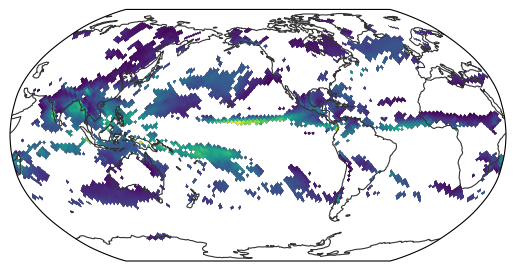

In [15]:
egh.healpix_show(
    pr.mean(dim="time")[
        (restrict_proportion(pr, proportion=0.5) & restrict_diff(pr, lim=2)).values
    ]
)

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


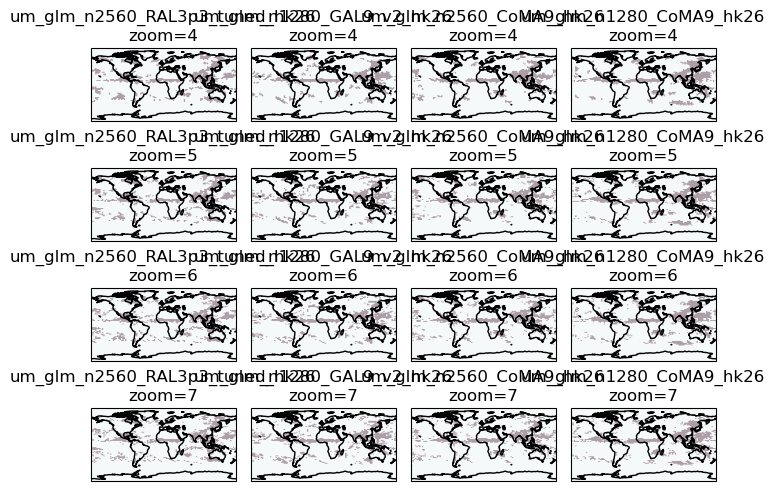

In [17]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "um_glm_n2560_RAL3p3_tuned_hk26",
    "um_glm_n1280_GAL9_v2_hk26",
    "um_glm_n2560_CoMA9_hk26",
    "um_glm_n1280_CoMA9_hk26",
]
zoom = 3
zooms = [4, 5, 6, 7]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    len(zooms),
    len(sims),
    subplot_kw={"projection": projection},
    layout="constrained",
)

for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes[zoom_ix, sim_ix]
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        ds_latlon = hp_to_latlon(ds, zoom=3)

        pr = ds.pr * 3600 * 24
        pr["units"] = "mm day-1"
        hp_resampler = HEALPixResampler(nside=egh.get_nside(pr))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            restrict_proportion(pr) & restrict_diff(pr),
            resampler=hp_resampler,
            ax=ax,
            alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}\nzoom={zoom}")
#         ().plot.contour(ax=ax)

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


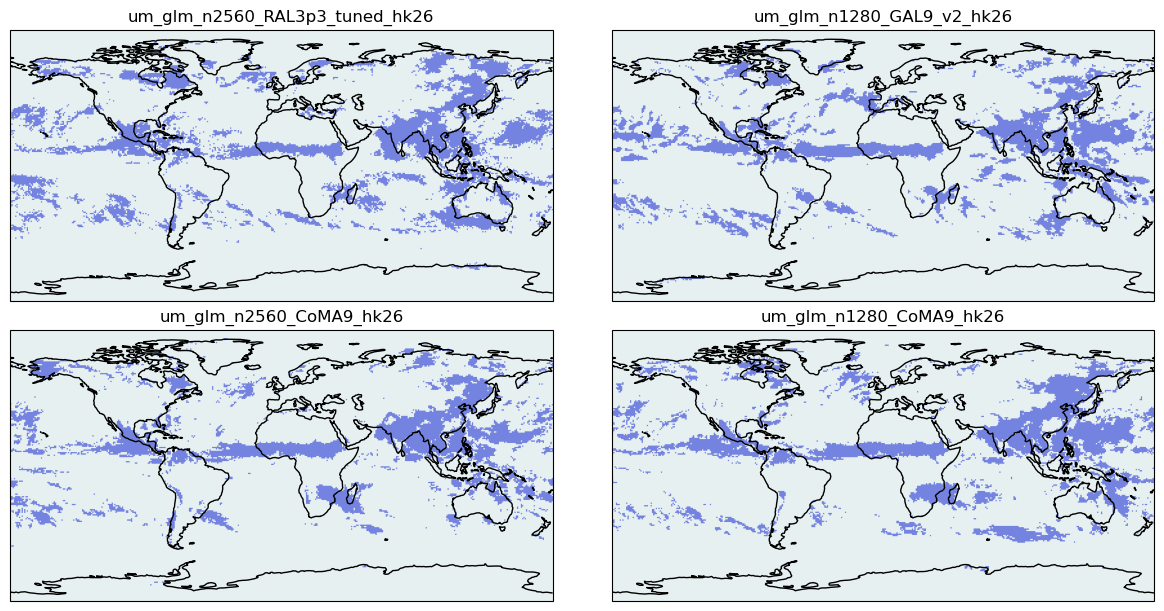

In [22]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "um_glm_n2560_RAL3p3_tuned_hk26",
    "um_glm_n1280_GAL9_v2_hk26",
    "um_glm_n2560_CoMA9_hk26",
    "um_glm_n1280_CoMA9_hk26",
]
zoom = 3
zooms = [7]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    int(len(sims) / 2),
    figsize=(12,6),
    subplot_kw={"projection": projection},
    layout="constrained",
)

for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes.ravel().tolist()[sim_ix]
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        ds_latlon = hp_to_latlon(ds, zoom=3)

        pr = ds.pr * 3600 * 24
        pr["units"] = "mm day-1"
        hp_resampler = HEALPixResampler(nside=egh.get_nside(pr))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            restrict_proportion(pr) & restrict_diff(pr),
            resampler=hp_resampler,
            ax=ax,
            # alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2,
            vmax=2
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}")
#         ().plot.contour(ax=ax)